# 05 — Scoring the Holdout Set

**Purpose:** Score a new batch of trades using only the *saved* model objects — no retraining.

**Why this matters:** In production, the model is trained once on historical data and then used to score new incoming trades. Retraining every time new data arrives would be expensive and would cause the model's definition of "normal" to shift over time. This notebook validates that the full scoring pipeline works end-to-end with data the model has never seen.

The holdout set is 20% of the synthetic trades that were set aside *before* training. It contains some injected anomaly accounts, so we can check whether the model still finds them in genuinely new data.

What we check here:
- Does the scoring pipeline run without errors on the holdout data?
- Are the score distributions from holdout similar to what we saw in training? (They should be — the data came from the same generator)
- Does recall on injected anomalies hold up in the holdout set?

In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")  # non-interactive backend
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from aml_anomaly.models.score import score_trades

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")
OUTPUTS_DIR = Path("../outputs")

In [2]:
holdout_trades = pd.read_csv(DATA_DIR / "holdout" / "new_trades.csv", parse_dates=["trade_date"])
accounts       = pd.read_csv(DATA_DIR / "raw" / "accounts.csv", parse_dates=["account_open_date"])
securities     = pd.read_csv(DATA_DIR / "raw" / "securities.csv")
injected       = pd.read_csv(DATA_DIR / "raw" / "injected_anomalies.csv")

print(f"Holdout trades: {len(holdout_trades):,}")
print(f"Unique accounts in holdout: {holdout_trades['account_id'].nunique():,}")

Holdout trades: 26,708
Unique accounts in holdout: 1,643


## 1. Run the scoring pipeline

The `score_trades()` function applies the same feature engineering pipeline and then loads the fitted scaler, PCA, and models from disk. It never fits anything new.

In [3]:
scores = score_trades(
    trades=holdout_trades,
    accounts=accounts,
    securities=securities,
    models_dir=MODELS_DIR,
)

scores["is_injected"] = scores["account_id"].isin(injected["account_id"])

print(f"Scored accounts: {len(scores):,}")
print(f"Flagged (top 4%): {scores['anomaly_flag'].sum()}")
print(f"Injected anomaly accounts in holdout: {scores['is_injected'].sum()}")

Building feature matrix from new trades...
  Computing velocity features...
  Computing concentration features...
  Computing behavioral features...
  Computing network features...
  Feature matrix: 2000 accounts × 35 features
Loading fitted model objects...
Applying preprocessing (no refitting)...
Scoring with Isolation Forest...
Scoring with Local Outlier Factor (LOF)...
Computing ensemble scores...

Scoring complete.
  Accounts scored: 2,000
  Flagged (top 4%): 80

Generating analyst reports...
  Anomaly scores: 2,000 accounts → outputs/anomaly_scores.csv
  Building analyst report for 80 flagged accounts...
  Flagged accounts report → outputs/flagged_accounts.xlsx
    Tab 1 — Summary:              80 accounts
    Tab 2 — Feature Detail:        400 rows
    Tab 3 — Supporting Trades:     725 trades
    Tab 4 — Population Benchmarks: 33 features
Scored accounts: 2,000
Flagged (top 4%): 80
Injected anomaly accounts in holdout: 75


## 2. Score distribution on holdout

This should look similar to the training score distribution in notebook 04. A major shift would suggest a data distribution problem.

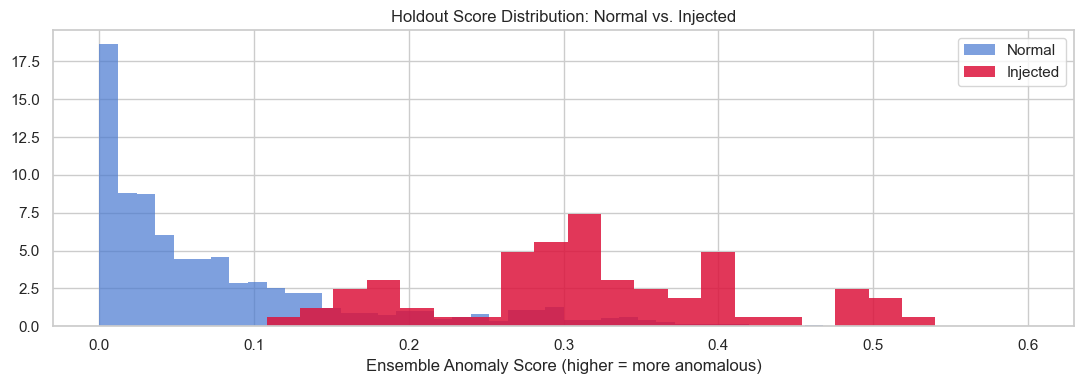

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))

normal_scores  = scores[~scores["is_injected"]]["anomaly_score"]
anomaly_scores = scores[scores["is_injected"]]["anomaly_score"]

ax.hist(normal_scores,  bins=50, alpha=0.7, label="Normal",   density=True, edgecolor="none")
ax.hist(anomaly_scores, bins=20, alpha=0.85, label="Injected", color="crimson", density=True, edgecolor="none")
ax.set_xlabel("Ensemble Anomaly Score (higher = more anomalous)")
ax.set_title("Holdout Score Distribution: Normal vs. Injected")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Recall on injected anomalies in holdout

The key test: does the model still find injected anomalies in data it was never trained on?

In [5]:
holdout_injected = scores[scores["is_injected"]].merge(
    injected[["account_id", "anomaly_pattern"]], on="account_id", how="left"
)

overall_recall = holdout_injected["anomaly_flag"].mean()
print(f"Holdout recall: {overall_recall:.1%}  ({holdout_injected['anomaly_flag'].sum()} of {len(holdout_injected)} injected accounts flagged)")

print("\nRecall by pattern:")
by_pattern = holdout_injected.groupby("anomaly_pattern")["anomaly_flag"].agg(["sum", "count"])
by_pattern["recall"] = by_pattern["sum"] / by_pattern["count"]
print(by_pattern.rename(columns={"sum": "flagged", "count": "total"}).to_string())

Holdout recall: 36.0%  (27 of 75 injected accounts flagged)

Recall by pattern:
                        flagged  total    recall
anomaly_pattern                                 
illiquid_concentration        0     15  0.000000
off_hours_clustering          8     15  0.533333
smurfing                     13     15  0.866667
velocity_spike                0     15  0.000000
wash_trading                  6     15  0.400000


## 4. Top flagged accounts preview

Inspect the top 20 accounts by anomaly score to get a first look at the analyst-facing output before the full report is generated.

In [6]:
top20 = scores.sort_values("anomaly_score", ascending=False).head(20)
top20 = top20.merge(accounts[["account_id", "account_type", "risk_tier", "is_pep"]], on="account_id", how="left")

display_cols = ["anomaly_rank", "account_id", "anomaly_score", "if_score", "lof_score",
                "account_type", "risk_tier", "is_pep", "is_injected"]
print(top20[display_cols].to_string(index=False))

 anomaly_rank account_id  anomaly_score  if_score    lof_score  account_type  risk_tier  is_pep  is_injected
            1  ACC-00329       0.600000  1.000000 1.570061e-09        Retail          2   False        False
            2  ACC-00713       0.560352  0.933921 1.513409e-10 Institutional          5   False        False
            3  ACC-01385       0.550687  0.917811 2.133763e-10 Broker-Dealer          1   False        False
            4  ACC-01492       0.540440  0.900733 9.439264e-11 Institutional          2   False         True
            5  ACC-00925       0.517184  0.861973 1.359485e-10        Retail          2   False         True
            6  ACC-01890       0.501185  0.835309 1.031193e-10        Retail          2   False         True
            7  ACC-00153       0.501104  0.835174 1.240567e-10        Retail          2   False         True
            8  ACC-00722       0.496926  0.828210 1.406834e-10        Retail          1   False         True
            9  ACC-

## 5. Save scored output

Write the full scores to `outputs/` for use in notebook 06.

In [7]:
scores.to_csv(OUTPUTS_DIR / "anomaly_scores.csv", index=False)
print(f"Saved {len(scores)} scored accounts to outputs/anomaly_scores.csv")

Saved 2000 scored accounts to outputs/anomaly_scores.csv
